In [1]:
# !pip install pandas numpy matplotlib seaborn holidays

## Data cleansing

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
def wrangle(path, col_1, col_2):
    # Import data
    df = pd.read_csv(path)

    # Convert to datetime
    df[col_1] = pd.to_datetime(df[col_1])

    # Rename the column to 'Date'
    df.rename(columns={col_1: 'Date'}, inplace=True)

    # Replace missing values
    df[col_2] = df[col_2].replace('.', pd.NA)

    # Convert to numeric, coercing errors to NaN
    df[col_2] = pd.to_numeric(df[col_2], errors='coerce')

    # Only select data between 2000-01-01 and 2024-12-31
    df = df[(df['Date'] >= '2000-01-01') & (df['Date'] <= '2024-12-31')]

    # Set index
    df = df.set_index('Date')

    return df

In [4]:
vix = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/VIX.csv",
              "Date",
              "Close")
vix

,Close
Date,
2000-01-03,24.69
2000-01-04,29.64
2000-01-05,28.15
2000-01-06,28.13
2000-01-07,23.20
...,...
2024-12-24,14.27
2024-12-26,14.73
2024-12-27,15.95


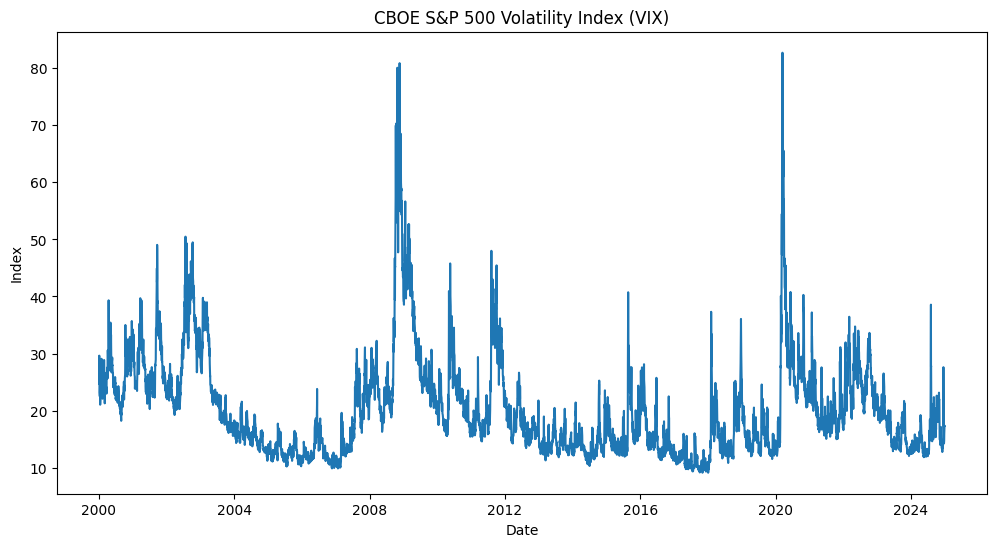

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(vix.index, vix['Close'])
plt.xlabel('Date')
plt.ylabel('Index')
plt.title("CBOE S&P 500 Volatility Index (VIX)");

In [6]:
JPY_USD = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/jpy_usd.csv",
                                    "Date",
                                    "Close")
JPY_USD

,Close
Date,
2000-01-03,101.56
2000-01-04,103.25
2000-01-05,104.27
2000-01-06,105.31
2000-01-07,105.35
...,...
2024-12-25,157.13
2024-12-26,158.00
2024-12-27,157.84


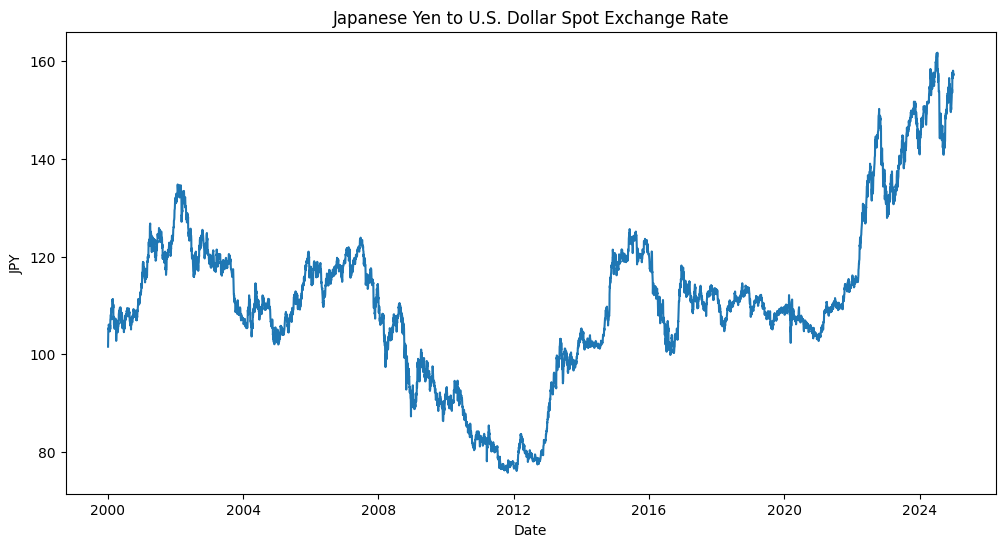

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(JPY_USD.index, JPY_USD['Close'])
plt.xlabel('Date')
plt.ylabel('JPY')
plt.title("Japanese Yen to U.S. Dollar Spot Exchange Rate");

In [8]:
jpy_1m_forward_rate = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/jpy_1m_forward_rate.csv",
                   "Date",
                   "Close")

jpy_1m_forward_rate

,Close
Date,
2000-01-03,101.190
2000-01-04,102.550
2000-01-05,103.190
2000-01-06,104.270
2000-01-07,105.310
...,...
2024-03-18,149.108
2024-03-19,149.826
2024-03-20,151.456


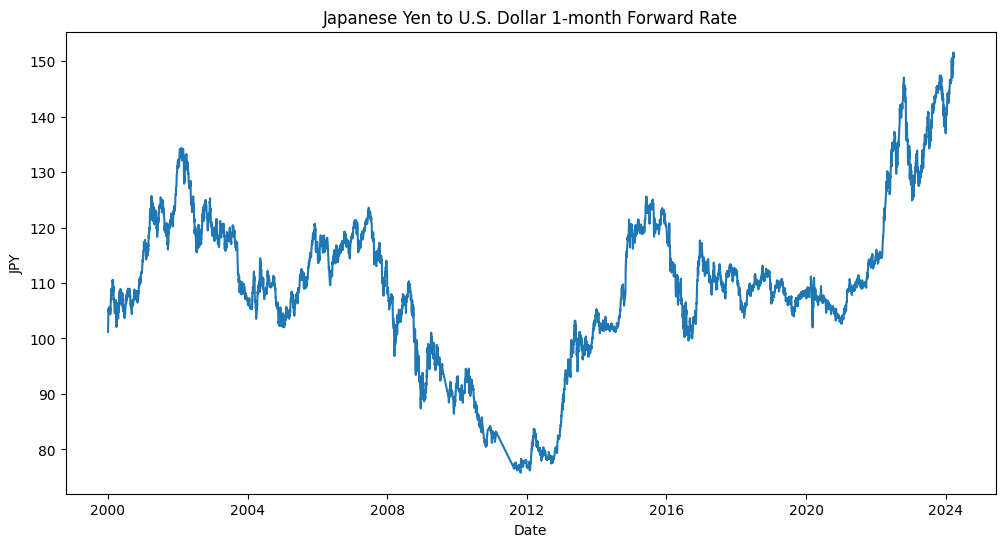

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(jpy_1m_forward_rate.index, jpy_1m_forward_rate['Close'])
plt.xlabel('Date')
plt.ylabel('JPY')
plt.title("Japanese Yen to U.S. Dollar 1-month Forward Rate");

#### Combining the data frames

In [10]:

# Renaming columns 
vix.rename(columns={"Close": "VIX"}, inplace=True)
JPY_USD.rename(columns={"Close": "spot_rate"}, inplace=True)
jpy_1m_forward_rate.rename(columns={"Close": "forward_rate_1month"}, inplace=True)

# Performing outer joins to keep all data
combined_df = pd.merge(vix, JPY_USD, on='Date', how='outer')
combined_df = pd.merge(combined_df, jpy_1m_forward_rate, on='Date', how='outer')

# Sorting by date for a cleaner view
combined_df.sort_index(inplace=True)

# Displaying the final dataframe and saving it
print(combined_df.head(10)) 
print(combined_df.tail(10)) 
combined_df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/combined_data_full.csv", index=True)

              VIX  spot_rate  forward_rate_1month
Date                                             
2000-01-03  24.69     101.56               101.19
2000-01-04  29.64     103.25               102.55
2000-01-05  28.15     104.27               103.19
2000-01-06  28.13     105.31               104.27
2000-01-07  23.20     105.35               105.31
2000-01-10  22.51     105.10               104.76
2000-01-11  23.93     106.07               105.44
2000-01-12  24.63     105.90               105.41
2000-01-13  23.35     106.04               105.59
2000-01-14  21.05     105.78               105.66
              VIX  spot_rate  forward_rate_1month
Date                                             
2024-12-18  27.62     154.80                  NaN
2024-12-19  24.09     157.66                  NaN
2024-12-20  18.36     156.41                  NaN
2024-12-23  16.78     157.18                  NaN
2024-12-24  14.27     157.18                  NaN
2024-12-25    NaN     157.13                  NaN


In [11]:
print(f"The number of non-NaN values: \n{combined_df.count()}")
print("\n")
print(f"The number of NaN values: \n{combined_df.isna().sum()}")

The number of non-NaN values: 
VIX                    6286
spot_rate              6674
forward_rate_1month    6052
dtype: int64


The number of NaN values: 
VIX                    408
spot_rate               20
forward_rate_1month    642
dtype: int64


In [12]:
# # Interpolation to fill missing values
# combined_df = combined_df.interpolate(method='time').ffill()

# Drop rows with NaN values
combined_df.dropna(inplace=True)

# Count NaN values in each column
print(f"The number of non-NaN values: \n{combined_df.count()}")
print("\n")
print(f"The number of NaN values: \n{combined_df.isna().sum()}")

The number of non-NaN values: 
VIX                    5825
spot_rate              5825
forward_rate_1month    5825
dtype: int64


The number of NaN values: 
VIX                    0
spot_rate              0
forward_rate_1month    0
dtype: int64


In [13]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5825 entries, 2000-01-03 to 2024-03-22
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   VIX                  5825 non-null   float64
 1   spot_rate            5825 non-null   float64
 2   forward_rate_1month  5825 non-null   float64
dtypes: float64(3)
memory usage: 182.0 KB


In [14]:
combined_df.describe()

,VIX,spot_rate,forward_rate_1month
count,5825.000000,5825.000000,5825.000000
mean,20.328754,110.457159,109.927722
std,8.996459,14.734258,14.198259
min,9.140000,75.790000,75.800000
25%,13.770000,104.180000,103.977305
50%,17.870000,110.020000,109.581479
75%,24.250000,118.440000,118.166667
max,82.690000,151.670000,151.515000


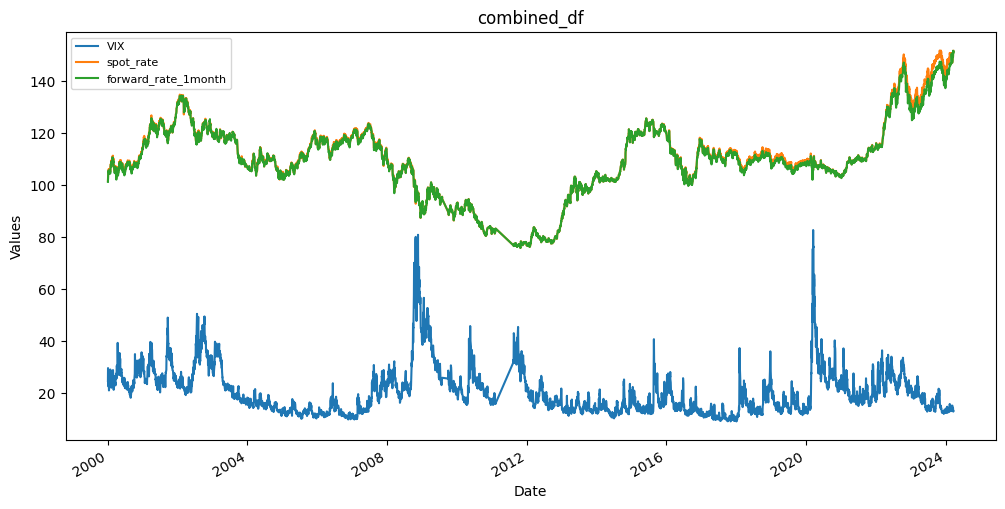

In [15]:
combined_df.plot(figsize=(12, 6), title="combined_df")
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend(loc='upper left', prop={'size': 8});

In [16]:
combined_df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/combined_data_full.csv", index=True)

### Compute carry trade returns